In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df=pd.read_csv('house_data_with_outliers.csv')
df.head()

,size_sqft,rooms,age_years,price
0,1623.6,1,32.1,237467.23
1,3352.1,4,4.2,472379.65
2,2696.0,3,8.1,425636.26
3,2296.0,4,44.9,344561.98
4,968.1,6,30.3,168628.85


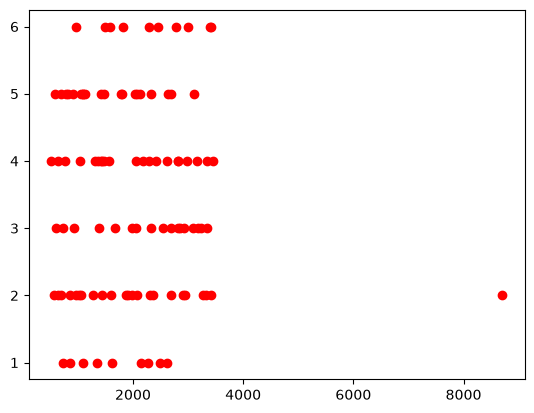

In [5]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c='r')

In [6]:
from sklearn.ensemble import IsolationForest
isf=IsolationForest(contamination=0.2)
isf.fit(df)
prediction=isf.predict(df)

In [7]:
index=np.where(prediction<0)
index

(array([ 1,  6,  9, 12, 22, 23, 34, 40, 42, 47, 50, 51, 52, 58, 68, 72, 85,
        90, 91, 92]),)

In [8]:
x=df.values

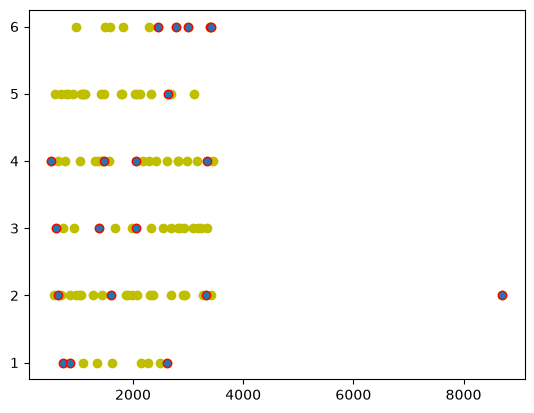

In [10]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c='y')
plt.scatter(x[index, 0], x[index, 1], edgecolors='r')

In [14]:
from sklearn.datasets import make_circles
x, y=make_circles(n_samples=750, factor=0.3, noise=0.1)

In [15]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.10)
dbscan.fit_predict(x)

array([-1,  0,  1,  2,  3, -1,  0,  3,  6,  0,  1,  4,  1,  3,  1, -1,  1,
        1,  5,  1,  6,  6,  1,  3,  1,  4,  1,  6,  7,  4, -1,  8,  0,  1,
        1,  6,  1,  1,  1,  1,  1,  5, -1, -1,  1,  1,  1,  3,  1,  1,  1,
        8,  3,  6,  1,  9,  1,  8,  6,  3,  3,  1,  1, -1,  1,  3,  5, -1,
        1,  1,  1,  0,  6,  1, 10,  1,  0,  1, 13,  6,  7,  7,  1,  1,  5,
        1,  3,  5,  1,  1,  1,  1,  1,  6,  1, 10, 11,  0,  1,  1, 10,  1,
       -1,  3,  0,  1,  1,  3, 10,  3,  1,  1,  0, 13,  3,  6,  1,  6,  4,
        1,  7,  1, -1,  1,  1,  1,  9,  1,  1,  6,  1, -1,  1,  3,  1,  1,
        1,  1,  5,  6,  1,  8,  9, -1, -1,  1,  8,  1,  6,  9, 10, 10,  1,
        1, 10,  1,  5,  5,  1,  1, 10,  1,  0,  1, 10, -1, -1, 11,  3,  1,
        8, -1,  9,  3,  1,  8,  1,  3,  1, -1,  3, 12,  3,  1,  1,  1,  6,
        1,  3,  1,  1,  1,  8,  0,  1, -1,  1, 12,  1,  1,  1,  8,  1,  0,
       13, 10,  1, -1,  9,  1,  1,  1,  6, -1,  3,  3,  0, 10,  1,  1,  1,
        4, -1,  6, -1,  1

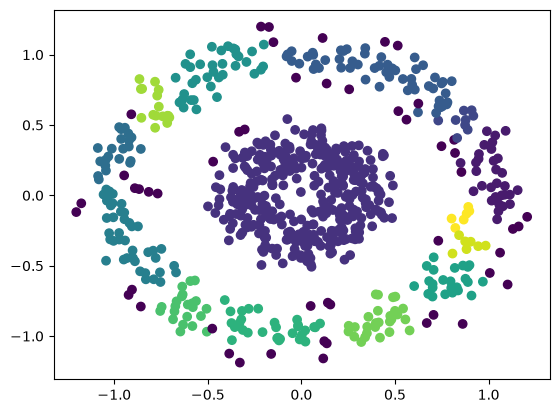

In [16]:
plt.scatter(x[:,0], x[:,1], c=dbscan.labels_)

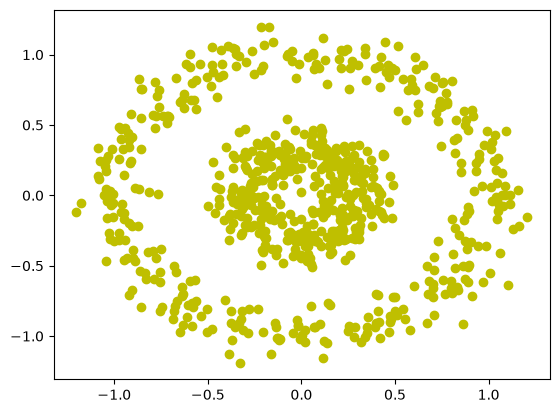

In [17]:
plt.scatter(x[:,0], x[:,1], c='y')

In [25]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

y_pred = lof.fit_predict(x)

# -1 = outlier, 1 = inlier
print(y_pred)

[ 1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1 -1  1 -1  1  1
  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1

In [26]:
from sklearn.neighbors import LocalOutlierFactor
lof=LocalOutlierFactor(n_neighbors=5,
                       contamination=0.4)
pred=lof.fit_predict(x)

In [27]:
print(pred)

[-1  1 -1  1  1 -1  1  1 -1 -1  1  1  1  1  1 -1  1  1  1  1 -1 -1  1  1
 -1  1 -1  1 -1 -1 -1 -1  1  1  1 -1  1  1  1 -1  1  1 -1 -1  1  1 -1 -1
  1 -1  1  1  1  1 -1  1  1  1  1 -1  1  1  1 -1 -1 -1 -1 -1  1 -1 -1 -1
  1  1 -1  1 -1 -1 -1  1  1  1 -1  1  1 -1  1  1  1  1  1 -1  1  1  1  1
  1  1  1  1  1 -1 -1  1  1 -1  1  1  1 -1  1 -1  1  1  1  1 -1  1 -1 -1
 -1  1 -1  1  1 -1 -1  1  1  1  1 -1 -1 -1  1  1  1 -1  1 -1 -1 -1  1 -1
 -1  1  1  1  1 -1  1  1  1 -1 -1 -1  1 -1  1 -1  1  1 -1  1 -1 -1 -1  1
  1  1  1 -1  1  1 -1 -1  1  1  1 -1 -1  1  1 -1 -1 -1  1  1  1  1 -1 -1
  1 -1 -1 -1 -1  1 -1  1 -1  1  1 -1  1  1  1 -1  1 -1  1 -1 -1 -1  1  1
 -1 -1  1  1  1 -1 -1  1 -1  1  1  1 -1  1 -1  1  1  1  1 -1  1  1  1 -1
  1  1 -1  1  1  1 -1 -1  1  1  1 -1 -1  1 -1  1  1  1 -1  1 -1 -1  1  1
  1 -1  1 -1 -1  1 -1  1  1  1 -1  1  1  1  1 -1  1  1  1  1 -1  1  1  1
 -1  1  1 -1 -1  1 -1 -1  1 -1 -1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1
  1  1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1

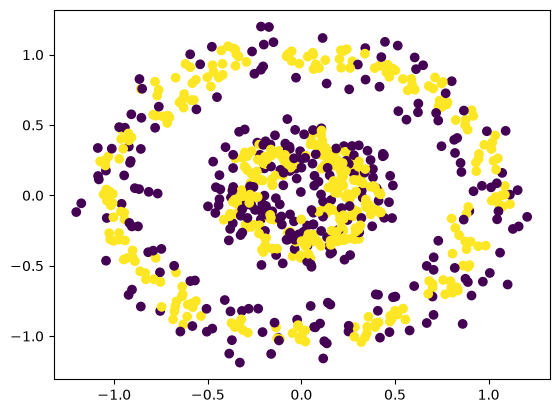

In [28]:
plt.scatter(x[:,0], x[:,1], c=pred)